In [ ]:
!pip install grad-cam

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [1]:
#############################################
# 1. Import Libraries & Mount Drive
#############################################
import os
import time
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

In [2]:
#############################################
# 2. Data Loading Function
#############################################
def get_data_loaders(data_dir, batch_size=32, img_size=(256, 256)):
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform)
    val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'valid'), transform)
    test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    return train_loader, val_loader, test_loader

In [3]:
#############################################
# 3. Define Training and Evaluation Functions
#############################################
def train_model(model, train_loader, val_loader, num_epochs, optimizer, criterion, device, scheduler=None):
    model.to(device)
    best_val_acc = 0.0
    best_model_path = 'best_model.pth'

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()
        val_loss /= val_total
        val_acc = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        epoch_time = time.time() - start_time
        samples_per_sec = total / epoch_time

        print(f"Epoch {epoch}/{num_epochs} | "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
              f"Time: {epoch_time:.2f}s | {samples_per_sec:.2f} samples/s")

        if scheduler:
            scheduler.step(epoch)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved to {best_model_path}")

    # Plot training and validation loss curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training and validation accuracy curves
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Val Accuracy')
    plt.title('Accuracy Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [4]:
def evaluate_model(model, test_loader, device, class_names, model_path='best_model.pth'):
    """
    Evaluates the model on the test dataset.

    Args:
        model: The model to evaluate.
        test_loader: DataLoader for the test dataset.
        device: The device to use for computation (e.g., 'cuda' or 'cpu').
        class_names: A list of class names.
        model_path: Path to the model file to load. Defaults to 'best_model.pth'.
    """
    model.load_state_dict(torch.load(model_path))  # Load from the specified path
    model.to(device)
    model.eval()

    y_true, y_pred = [], []
    total, correct = 0, 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    test_acc = 100 * correct / total
    print(f"\nTest Accuracy: {test_acc:.2f}%")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

In [ ]:
def plot_true_vs_predicted(model, test_loader, device, class_names, num_examples=16):
    model.load_state_dict(torch.load('best_model.pth'))
    model.to(device).eval()

    # Get a batch of test data
    inputs, labels = next(iter(test_loader))
    inputs = inputs.to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

    # Denormalize images for visualization
    def denormalize(image):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
        return image * std + mean

    # Plot true vs predicted images in a 4x4 grid
    plt.figure(figsize=(12, 12))  # Adjust figure size for 16 images
    for idx in range(num_examples):
        img = denormalize(inputs[idx]).cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)  # Clip to valid image range

        plt.subplot(4, 4, idx + 1)  # 4 rows, 4 columns
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[idx]]}\nPred: {class_names[predicted[idx]]}", fontsize=8)  # Smaller font size
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
class GradCAMWrapper:
    def __init__(self, model):
        self.model = model
        # Access features directly from the model
        self.target_layers = [self.model.features[-1]]
        self.cam = GradCAM(model=self.model,
                          target_layers=self.target_layers,
                          #use_cuda=torch.cuda.is_available()
                          )

    def visualize(self, input_tensor, rgb_img=None):
        grayscale_cam = self.cam(input_tensor=input_tensor)
        grayscale_cam = grayscale_cam[0, :]

        if rgb_img is None:
            rgb_img = input_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
            rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        return visualization

In [ ]:
def show_gradcam_examples(model, test_loader, device, num_examples=16):
    cam = GradCAMWrapper(model)
    model.eval()

    # Get a batch of test data
    inputs, labels = next(iter(test_loader))
    inputs = inputs.to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

    # Denormalize images for visualization
    def denormalize(image):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
        return image * std + mean

    # Plot Grad-CAM visualizations in a 4x4 grid
    plt.figure(figsize=(12, 12))  # Adjust figure size for 16 images
    for idx in range(num_examples):
        img = denormalize(inputs[idx]).cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)  # Clip to valid image range

        # Generate Grad-CAM visualization
        visualization = cam.visualize(inputs[idx].unsqueeze(0), img)

        plt.subplot(4, 4, idx + 1)  # 4 rows, 4 columns
        plt.imshow(visualization)
        plt.title(f"True: {class_names[labels[idx]]}\nPred: {class_names[predicted[idx]]}", fontsize=8)  # Smaller font size
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [5]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
#############################################
# 4. Set Paths, Extract Dataset & Create Data Loaders
#############################################
dataset_path = '/content/drive/MyDrive/My Datasets/Tea_Betel_Leaf_Final_Dataset(1).zip'
extract_path = '/content/data'
batch_size = 16
img_size = (256, 256)
num_classes = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
data_dir = os.path.join(extract_path, 'Tea_Betel_Leaf_Final_Dataset')
train_loader, val_loader, test_loader = get_data_loaders(data_dir, batch_size, img_size)
class_names = train_loader.dataset.classes
print("Classes:", class_names)

Classes: ['betel_Bacterial Leaf Disease', 'betel_Dried Leaf', 'betel_Fungal Brown Spot Disease', 'betel_Healthy Leaf', 'tea_algal_spot', 'tea_brown_blight', 'tea_gray_blight', 'tea_healthy', 'tea_helopeltis', 'tea_red_spot']


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [7]:
#############################################
# 5. Load Pre-trained MobileNetV3 Large & Modify Classifier
#############################################
model = models.mobilenet_v3_large(pretrained=True)
# Replace the final layer (assumes model.classifier is a Sequential module)
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, num_classes)

criterion = nn.CrossEntropyLoss()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 184MB/s]



Stage 1: Training only classifier layers
Epoch 1/40 | Train Loss: 0.5123 Acc: 83.55% | Val Loss: 0.2676 Acc: 90.53% | Time: 34.40s | 200.76 samples/s
Best model saved to best_model.pth


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2/40 | Train Loss: 0.2639 Acc: 90.62% | Val Loss: 0.2013 Acc: 92.48% | Time: 22.54s | 306.40 samples/s
Best model saved to best_model.pth
Epoch 3/40 | Train Loss: 0.2111 Acc: 92.14% | Val Loss: 0.2347 Acc: 92.08% | Time: 21.25s | 325.04 samples/s
Epoch 4/40 | Train Loss: 0.1856 Acc: 93.12% | Val Loss: 0.1910 Acc: 92.81% | Time: 22.34s | 309.12 samples/s
Best model saved to best_model.pth
Epoch 5/40 | Train Loss: 0.1593 Acc: 94.32% | Val Loss: 0.1611 Acc: 93.69% | Time: 24.20s | 285.40 samples/s
Best model saved to best_model.pth
Epoch 6/40 | Train Loss: 0.1425 Acc: 94.98% | Val Loss: 0.1597 Acc: 94.09% | Time: 21.26s | 324.85 samples/s
Best model saved to best_model.pth
Epoch 7/40 | Train Loss: 0.1279 Acc: 95.45% | Val Loss: 0.1546 Acc: 94.09% | Time: 22.61s | 305.38 samples/s
Epoch 8/40 | Train Loss: 0.1083 Acc: 96.19% | Val Loss: 0.1578 Acc: 94.43% | Time: 21.14s | 326.71 samples/s
Best model saved to best_model.pth
Epoch 9/40 | Train Loss: 0.1093 Acc: 96.32% | Val Loss: 0.1285

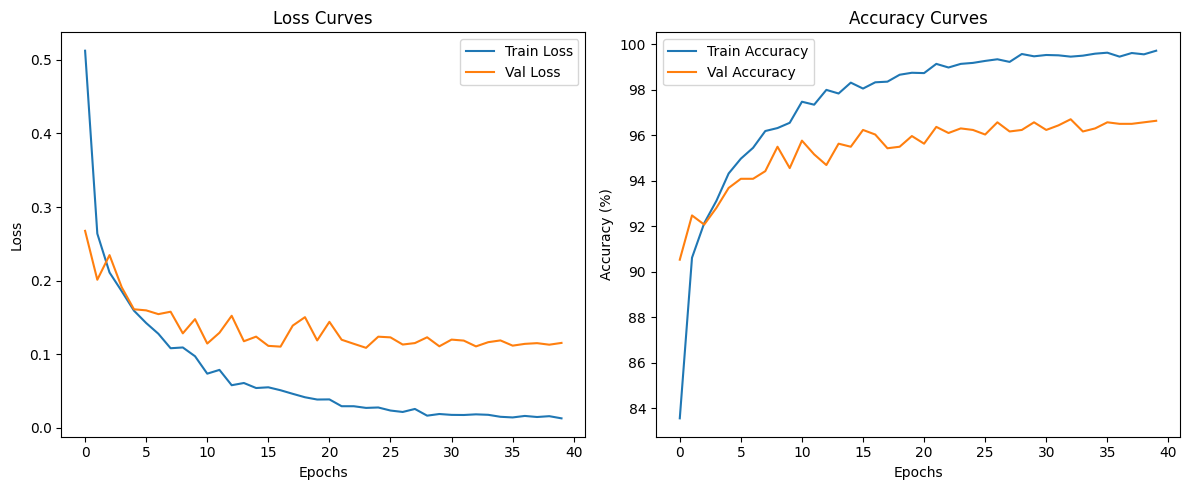

In [ ]:
#############################################
# 6. Stage 1: Train Only the Classification Layers
#############################################
print("\nStage 1: Training only classifier layers")
# Freeze feature extractor layers
for param in model.features.parameters():
    param.requires_grad = False

optimizer_stage1 = optim.Adam(model.classifier.parameters(), lr=3e-4)
scheduler = CosineAnnealingLR(optimizer_stage1, T_max=40)
train_model(model, train_loader, val_loader, num_epochs=40, optimizer=optimizer_stage1,
            criterion=criterion, device=device, scheduler=scheduler)

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

In [ ]:
# Analyze the model after Stage 1 training
print("\nModel Analysis After Stage 1 Training:")
summary(model, input_size=(1, 3, img_size[0], img_size[1]))


Model Analysis After Stage 1 Training:


Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 10]                   --
├─Sequential: 1-1                                  [1, 960, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         (432)
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         (32)
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidual: 2-2                       [1, 16, 128, 128]         --
│    │    └─Sequential: 3-4                        [1, 16, 128, 128]         (464)
│    └─InvertedResidual: 2-3                       [1, 24, 64, 64]           --
│    │    └─Sequential: 3-5                        [1, 24, 64, 64]           (3,440)
│    └─InvertedResidual: 2-4                       [1, 24, 64, 64]           --
│    │    └─Sequential


Test Accuracy: 96.13%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.88      0.93      0.90       148
               betel_Dried Leaf       1.00      1.00      1.00       148
betel_Fungal Brown Spot Disease       0.99      0.97      0.98       148
             betel_Healthy Leaf       0.92      0.89      0.91       148
                 tea_algal_spot       0.99      1.00      1.00       150
               tea_brown_blight       0.90      0.98      0.94       130
                tea_gray_blight       0.99      0.91      0.95       150
                    tea_healthy       0.97      0.99      0.98       150
                 tea_helopeltis       0.99      0.96      0.97       150
                   tea_red_spot       0.99      0.98      0.98       150

                       accuracy                           0.96      1472
                      macro avg       0.96      0.96      0.96      1472
  

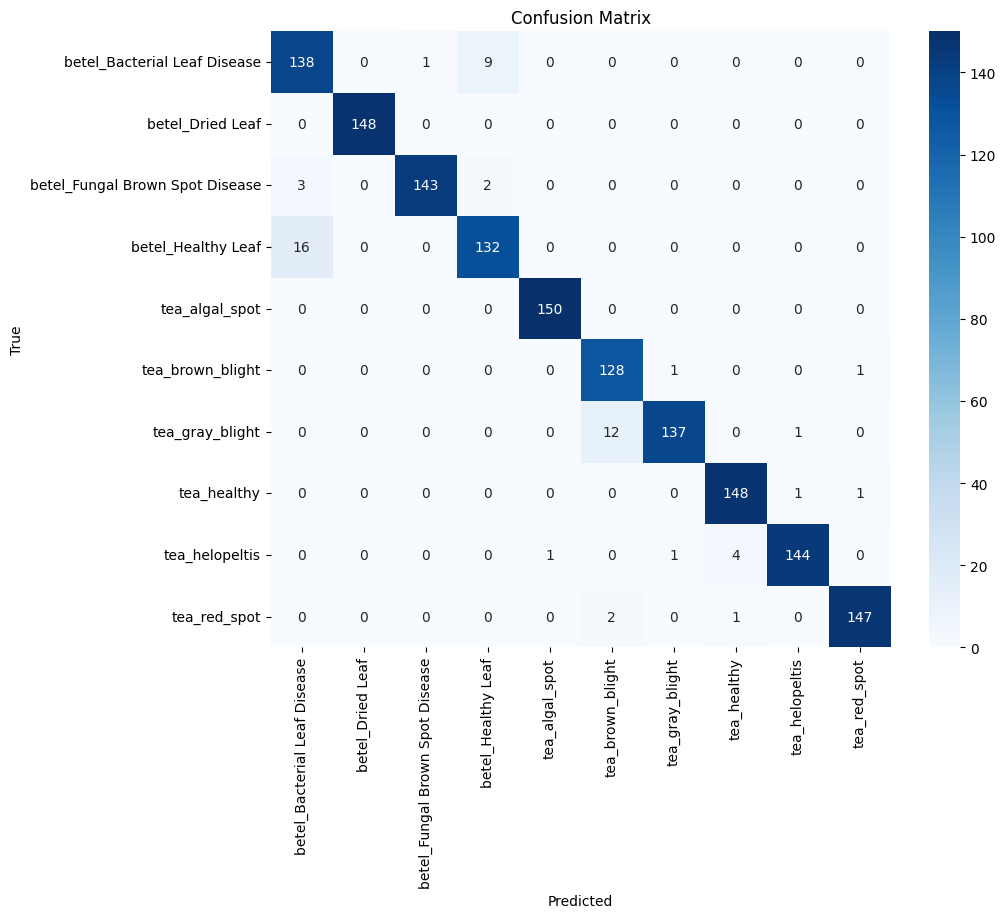

In [ ]:
evaluate_model(model, test_loader, device, class_names)

In [ ]:
plot_true_vs_predicted(model, test_loader, device, class_names)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#show_gradcam_examples(model, test_loader, device)

In [ ]:
#############################################
# 7. Stage 2: Fine-tune by Unfreezing Last 20 Layers
#############################################
print("\nStage 2: Fine-tuning last 20 layers")
# Freeze all parameters first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last 20 parameters (from the list of named parameters)
named_params = list(model.named_parameters())
for name, param in named_params[-20:]:
    param.requires_grad = True
    # Uncomment the next line to see which layers are being unfrozen
    print(f"Unfreezing: {name}")


Stage 2: Fine-tuning last 20 layers
Unfreezing: features.15.block.0.0.weight
Unfreezing: features.15.block.0.1.weight
Unfreezing: features.15.block.0.1.bias
Unfreezing: features.15.block.1.0.weight
Unfreezing: features.15.block.1.1.weight
Unfreezing: features.15.block.1.1.bias
Unfreezing: features.15.block.2.fc1.weight
Unfreezing: features.15.block.2.fc1.bias
Unfreezing: features.15.block.2.fc2.weight
Unfreezing: features.15.block.2.fc2.bias
Unfreezing: features.15.block.3.0.weight
Unfreezing: features.15.block.3.1.weight
Unfreezing: features.15.block.3.1.bias
Unfreezing: features.16.0.weight
Unfreezing: features.16.1.weight
Unfreezing: features.16.1.bias
Unfreezing: classifier.0.weight
Unfreezing: classifier.0.bias
Unfreezing: classifier.3.weight
Unfreezing: classifier.3.bias


Epoch 1/40 | Train Loss: 0.0848 Acc: 96.84% | Val Loss: 0.1941 Acc: 94.29% | Time: 38.12s | 181.15 samples/s
Best model saved to best_model.pth


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2/40 | Train Loss: 0.0446 Acc: 98.39% | Val Loss: 0.1631 Acc: 95.10% | Time: 23.59s | 292.69 samples/s
Best model saved to best_model.pth
Epoch 3/40 | Train Loss: 0.0404 Acc: 98.70% | Val Loss: 0.1847 Acc: 94.90% | Time: 23.33s | 296.02 samples/s
Epoch 4/40 | Train Loss: 0.0320 Acc: 98.81% | Val Loss: 0.1506 Acc: 95.50% | Time: 22.13s | 312.13 samples/s
Best model saved to best_model.pth
Epoch 5/40 | Train Loss: 0.0346 Acc: 98.83% | Val Loss: 0.1586 Acc: 96.10% | Time: 25.16s | 274.45 samples/s
Best model saved to best_model.pth
Epoch 6/40 | Train Loss: 0.0283 Acc: 99.12% | Val Loss: 0.1362 Acc: 96.31% | Time: 23.31s | 296.24 samples/s
Best model saved to best_model.pth
Epoch 7/40 | Train Loss: 0.0335 Acc: 98.99% | Val Loss: 0.1235 Acc: 96.31% | Time: 22.28s | 309.98 samples/s
Epoch 8/40 | Train Loss: 0.0248 Acc: 99.10% | Val Loss: 0.1498 Acc: 96.10% | Time: 24.64s | 280.22 samples/s
Epoch 9/40 | Train Loss: 0.0274 Acc: 99.02% | Val Loss: 0.1489 Acc: 95.84% | Time: 23.59s | 292.6

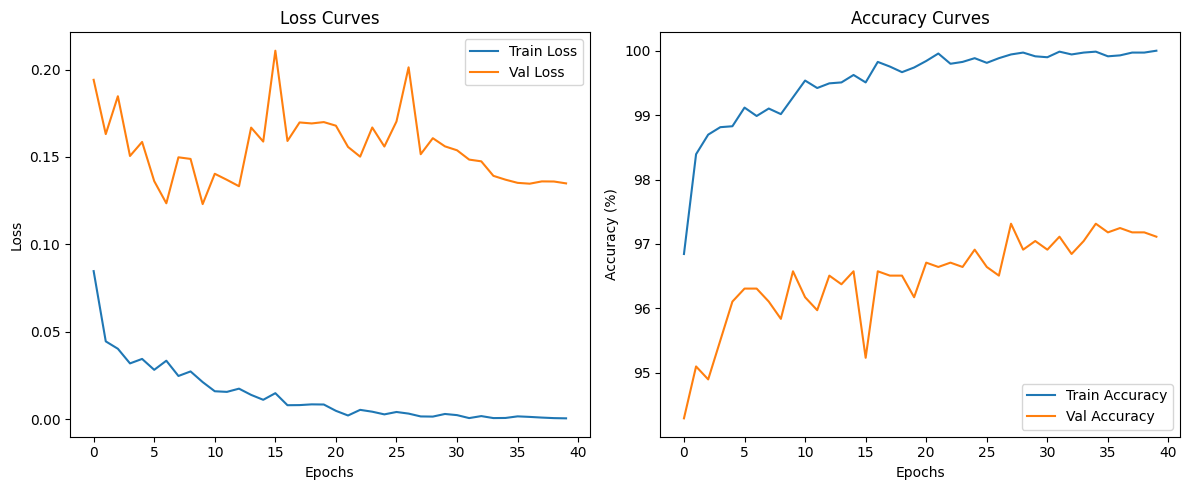

In [ ]:
params_to_update = [param for param in model.parameters() if param.requires_grad]
optimizer_stage2 = optim.Adam(params_to_update, lr=3e-4)
scheduler = CosineAnnealingLR(optimizer_stage2, T_max=40)
train_model(model, train_loader, val_loader, num_epochs=40, optimizer=optimizer_stage2,
            criterion=criterion, device=device, scheduler=scheduler)

In [ ]:
# Analyze the model after Stage 2 training
print("\nModel Analysis After Stage 2 Training:")
summary(model, input_size=(1, 3, img_size[0], img_size[1]))


Model Analysis After Stage 2 Training:


Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 10]                   --
├─Sequential: 1-1                                  [1, 960, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         (432)
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         (32)
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidual: 2-2                       [1, 16, 128, 128]         --
│    │    └─Sequential: 3-4                        [1, 16, 128, 128]         (464)
│    └─InvertedResidual: 2-3                       [1, 24, 64, 64]           --
│    │    └─Sequential: 3-5                        [1, 24, 64, 64]           (3,440)
│    └─InvertedResidual: 2-4                       [1, 24, 64, 64]           --
│    │    └─Sequential


Test Accuracy: 97.49%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.93      0.94      0.93       148
               betel_Dried Leaf       1.00      1.00      1.00       148
betel_Fungal Brown Spot Disease       0.99      1.00      0.99       148
             betel_Healthy Leaf       0.95      0.93      0.94       148
                 tea_algal_spot       1.00      0.99      0.99       150
               tea_brown_blight       0.93      0.99      0.96       130
                tea_gray_blight       0.98      0.95      0.96       150
                    tea_healthy       0.97      0.99      0.98       150
                 tea_helopeltis       1.00      0.97      0.99       150
                   tea_red_spot       0.99      0.99      0.99       150

                       accuracy                           0.97      1472
                      macro avg       0.97      0.98      0.97      1472
  

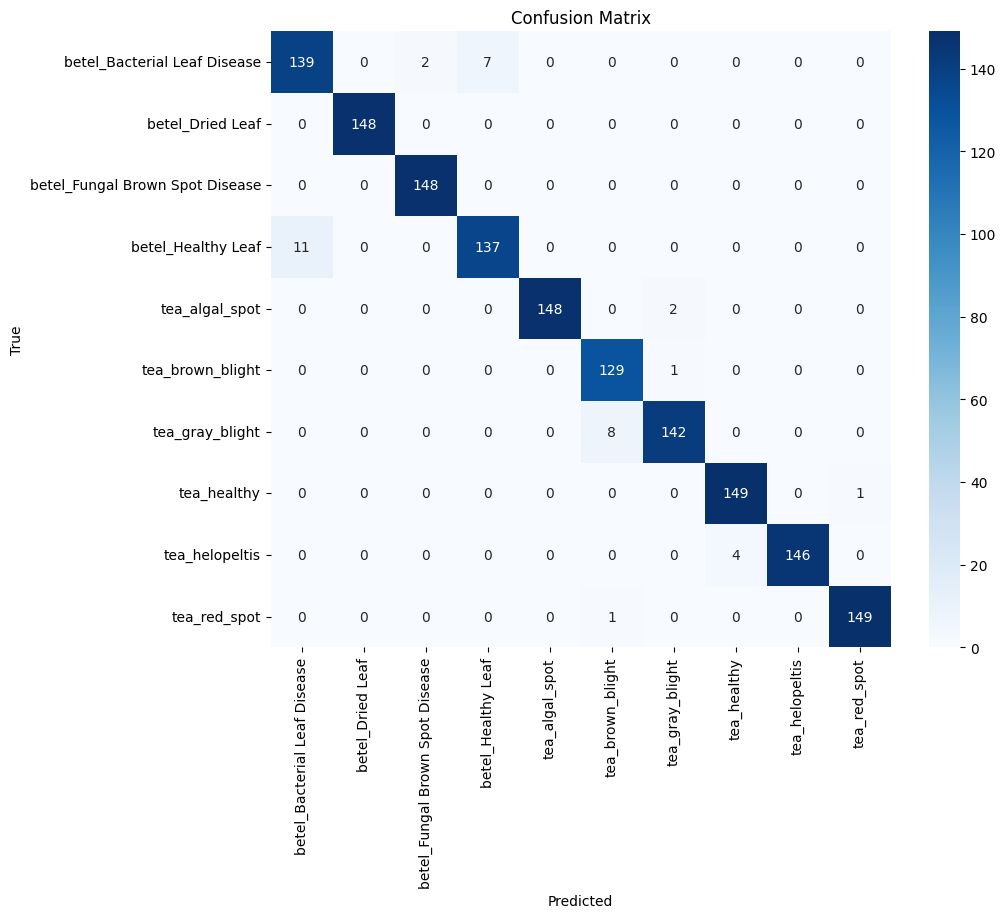

In [ ]:
evaluate_model(model, test_loader, device, class_names)

In [ ]:
plot_true_vs_predicted(model, test_loader, device, class_names)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
show_gradcam_examples(model, test_loader, device)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
torch.cuda.empty_cache()

In [ ]:
import os

# Define the path to your model in the Colab notebook
model_path_colab = 'best_model.pth'

# Define the path where you want to save the model in your Google Drive
model_path_drive = '/content/drive/My Drive/MyModels/mobnetV3_large_baseline_best_model.pth'  # Create the "MyModels" folder if it doesn't exist

# Save the model to Google Drive
try:
    os.makedirs(os.path.dirname(model_path_drive), exist_ok=True)  # Create the directory if it doesn't exist
    !cp "{model_path_colab}" "{model_path_drive}"
    print(f"Model saved to: {model_path_drive}")
except Exception as e:
    print(f"Error saving model: {e}")

Model saved to: /content/drive/My Drive/MyModels/mobnetV3_large_baseline_best_model.pth


In [8]:
_, _, test_loader2 = get_data_loaders(data_dir, batch_size, img_size)

In [9]:
# Load the saved model from Google Drive
model_path_drive = '/content/drive/My Drive/MyModels/mobnetV3_large_baseline_best_model.pth'
model.load_state_dict(torch.load(model_path_drive))

# Move the model to the appropriate device
model.to(device)

# Evaluate the model
# evaluate_model(model, test_loader2, device, class_names, model_path=model_path_drive)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


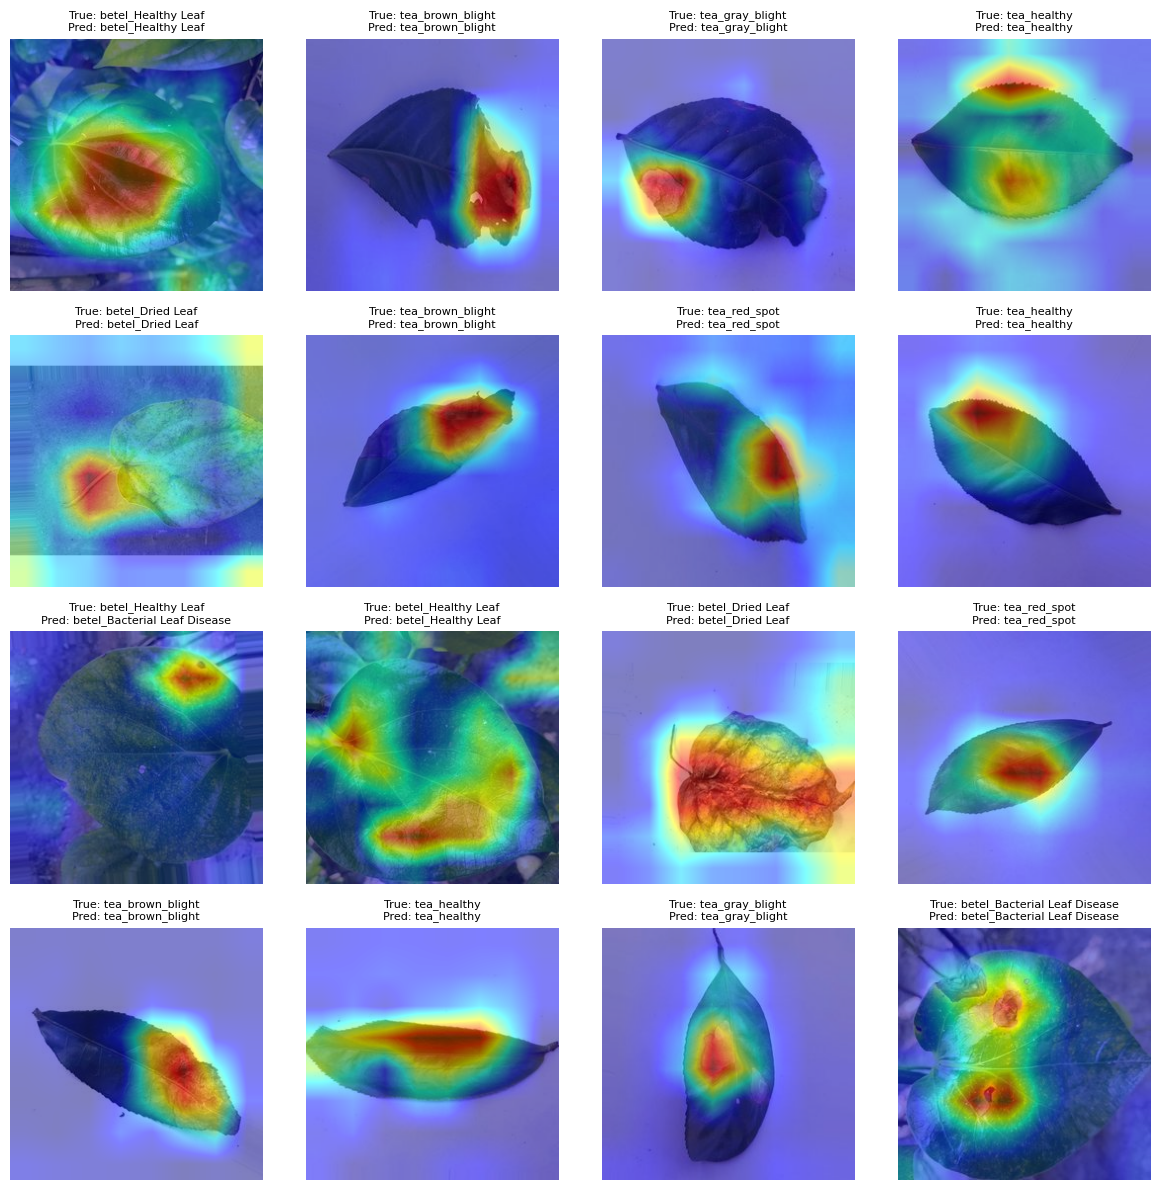

In [ ]:
show_gradcam_examples(model, test_loader2, device)

In [ ]:
# #############################################
# # 8. Stage 3: Retrain the Entire Model
# #############################################
# print("\nStage 3: Retraining the entire model")
# # Unfreeze all layers
# for param in model.parameters():
#     param.requires_grad = True

# optimizer_stage3 = optim.Adam(model.parameters(), lr=1e-5)
# scheduler = CosineAnnealingLR(optimizer_stage3, T_max=10)
# train_model(model, train_loader, val_loader, num_epochs=10, optimizer=optimizer_stage3,
#             criterion=criterion, device=device, scheduler=scheduler)

In [ ]:
# #############################################
# # 9. Evaluate the Best Model on the Test Set
# #############################################
# evaluate_model(model, test_loader, device, class_names)

In [ ]:
# plot_true_vs_predicted(model, test_loader, device, class_names)

In [ ]:
# show_gradcam_examples(model, test_loader, device)